---
title: "Modul 7 Sains Data: Klasifikasi Gambar dan Pengantar Convolution Neural Network"
subtitle: "Klasifikasi Gambar dengan Neural Network"
image: https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal18.png
description: "Offline di Departemen Matematika"
date: 04/29/2026
page-navigation: true
format: html
---

Kembali ke [Sains Data](./saindat2026genap.qmd)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Klasifikasi Gambar dengan *flatten*

Gambar atau citra *(image)* adalah sekumpulan pixel yang disusun secara dua dimensi. Sejauh ini, *neural network* yang kita pelajari memiliki satu *input layer* yang "flat" atau datar. Sehingga, apabila kita ingin meng-*input* data citra ke dalam *neural network*, caranya adalah dengan *flatten*, yaitu data citra yang mula-mula dua dimensi itu disusun ulang menjadi satu dimensi.

Di Keras, ada *layer* istimewa untuk melakukan *flatten* untuk gambar berukuran `a` kali `b` pixel:

`keras.layers.Flatten(input_shape = (a, b))`

Ketika berurusan dengan data citra, *layer* ini menggantikan `InputLayer` yang biasa kita gunakan.

## Persiapan dataset Fashion MNIST

Mari kita coba menggunakan dataset Fashion MNIST yang sudah tersedia dari Keras:

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
print(f'X_train_full shape: {X_train_full.shape}')
print(f'y_train_full shape: {y_train_full.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=1/6, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (50000, 28, 28)
y_train shape: (50000,)
X_val shape: (10000, 28, 28)
y_val shape: (10000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

Ada 10 kelas:

In [ ]:
print(set(y_train))

{np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)}


In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [ ]:
print(len(class_names))

10


Kita lihat salah satu gambarnya:

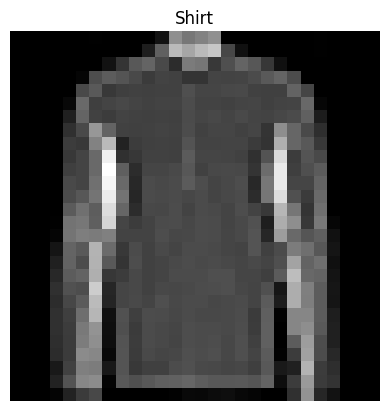

In [ ]:
#@title Slider to look for some image examples {run: "auto"}
idx = 13779 #@param {type:"slider", min:0, max:49999, step:1}

plt.imshow(X_train[idx], cmap='gray')
plt.title(class_names[y_train[idx]])
plt.axis('OFF')
plt.show()

## Menyusun *neural network* dan *training*

In [ ]:
keras.backend.clear_session()

In [ ]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(units=100, activation=keras.activations.relu),
        keras.layers.Dense(units=50, activation=keras.activations.relu),
        keras.layers.Dense(units=10, activation=keras.activations.softmax)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.CategoricalAccuracy()]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,060 (328.36 KB)

 Trainable params: 84,060 (328.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=256
)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - categorical_accuracy: 0.0698 - loss: 0.6786 - val_categorical_accuracy: 0.0660 - val_loss: 0.4998
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - categorical_accuracy: 0.0683 - loss: 0.4369 - val_categorical_accuracy: 0.0675 - val_loss: 0.4173
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - categorical_accuracy: 0.0664 - loss: 0.3940 - val_categorical_accuracy: 0.0701 - val_loss: 0.3970
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - categorical_accuracy: 0.0557 - loss: 0.3605 - val_categorical_accuracy: 0.0700 - val_loss: 0.3866
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - categorical_accuracy: 0.0653 - loss: 0.3434 - val_categorical_accuracy: 0.0649 - val_loss: 0.3843
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - categorical_accuracy: 0.0589 - loss: 0.3280 - val_categorical_accuracy: 0.0690 - val_loss: 0.3788
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - categorical_accuracy: 0.0673 - lo

In [ ]:
pd.DataFrame(history1.history).to_csv("./keras_sequential_history1.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_sequential_history1.csv](./Modul7/keras_sequential_history1.csv)

In [ ]:
history1_df = pd.read_csv("./keras_sequential_history1.csv")

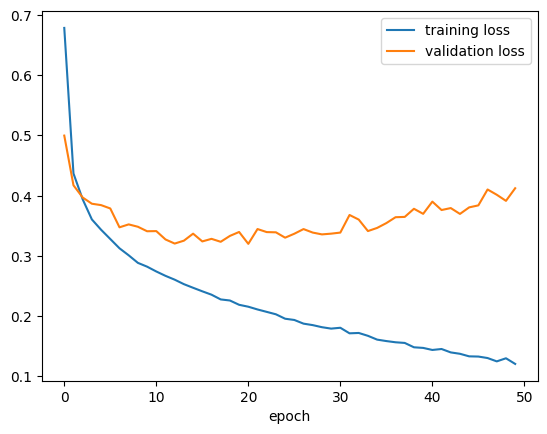

In [ ]:
plt.plot(history1_df["loss"], label = "training loss")
plt.plot(history1_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [ ]:
model.save("./keras_sequential_image_flatten.keras")

## Hasil prediksi

In [ ]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred

array([[2.3255573e-07, 6.8715373e-13, 4.8452992e-10, ..., 4.0070943e-05,
        7.4082754e-11, 9.9995774e-01],
       [2.4705474e-07, 6.3406563e-23, 9.9977636e-01, ..., 6.0544784e-22,
        5.7611311e-16, 1.0497308e-19],
       [6.9932263e-12, 9.9999994e-01, 4.9629018e-13, ..., 1.2882070e-20,
        2.8977601e-15, 5.8007476e-17],
       ...,
       [1.5269237e-09, 1.8880624e-23, 2.1215406e-10, ..., 6.3853453e-19,
        9.9999994e-01, 4.3363592e-19],
       [1.2524308e-11, 9.9999994e-01, 7.8069028e-14, ..., 3.6561142e-17,
        4.2744394e-13, 8.9643435e-14],
       [1.7552978e-08, 1.2925562e-15, 4.8392163e-08, ..., 5.8510761e-08,
        4.5267003e-09, 1.2477504e-10]], dtype=float32)

In [ ]:
y_pred[123]

array([6.4850452e-15, 9.5243375e-19, 2.5446429e-22, 1.2883222e-16,
       5.1601930e-18, 1.2468863e-11, 5.3251053e-28, 3.6245498e-07,
       2.2436268e-15, 9.9999958e-01], dtype=float32)

In [ ]:
np.argmax(y_pred[123])

np.int64(9)

Kita bisa melihat hasil prediksi:

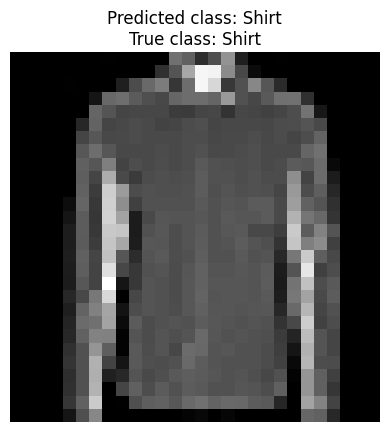

In [ ]:
#@title Slider to look for some prediction examples {run: "auto"}
idx = 4518 #@param {type:"slider", min:0, max:9999, step:1}

plt.imshow(X_test[idx], cmap='gray')
plt.title(
    f"Predicted class: {class_names[int(np.argmax(y_pred[idx]))]}\n" +
    f"True class: {class_names[y_test[idx]]}"
)
plt.axis('OFF')
plt.show()

Confusion matrix, without normalization
[[863   3  21  36   3   3  65   0   6   0]
 [  1 973   0  20   4   0   1   0   1   0]
 [ 21   3 808  13 118   0  37   0   0   0]
 [ 22   6  18 892  44   0  14   0   4   0]
 [  1   1  79  27 859   0  31   0   2   0]
 [  0   1   0   2   0 944   0  25   2  26]
 [157   4 110  37 116   1 571   0   4   0]
 [  0   0   0   0   0  15   0 964   0  21]
 [  8   1  16   6   5   2   4   3 955   0]
 [  1   0   0   0   0   7   0  46   0 946]]


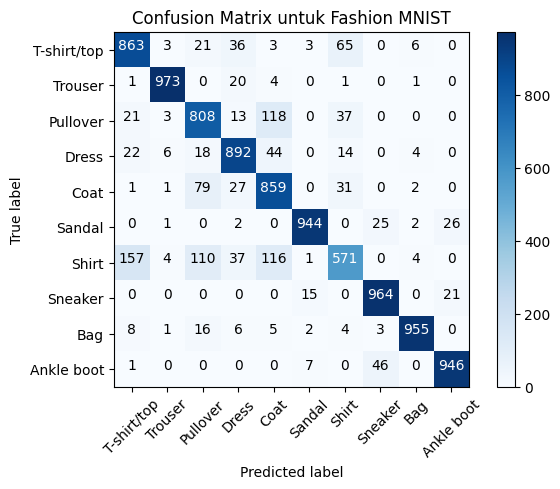

In [ ]:
#visualisasi confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

# argument max
y_pred_labels = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_labels, labels=np.arange(len(class_names)))

plot_confusion_matrix(cm, class_names, title='Confusion Matrix untuk Fashion MNIST', normalize=False)
plt.show()

# Pengantar CNN *(Convolutional Neural Network)*

Sebenarnya, menerima input gambar dengan teknik *flatten* itu kurang efektif.

- Dengan *dense layer*, bahkan dua pixel yang sangat jauh itu juga terhubungkan, padahal seharusnya tidak berhubungan.

- Karena itu juga, tidak ada penekanan hubungan antara dua pixel yang saling berdekatan.

Alangkah baiknya, ada teknik input gambar yang bisa mempertimbangkan bagaimana hubungan suatu pixel dengan pixel-pixel di sekitarnya saja, daripada dengan semua pixel.

*Convolutional Neural Network* (CNN) mencoba mengatasi hal ini. Ciri khasnya adalah adanya dua jenis *layer* baru:

- *convolution layer*

- *pooling layer*, biasanya *max pooling*

Kedua *layer* baru ini bersifat *sparse*, yaitu beberapa *neuron* terhubung dengan beberapa *neuron* saja, tidak dengan semuanya.

Gambar berikut ini membandingkan antara *sparse layer* dengan *dense layer*:

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/goodfellow_dl_hal337.png)

Sumber gambar: Goodfellow, et. al. (2016) hal. 337

## Konsep *convolution layer*

Suatu *convolution layer* menghitung "konvolusi" *(convolution)*.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/kotu_dscp10_hal325.png)

Sumber gambar: Kotu, hal. 325

Perhitungan konvolusi selalu melibatkan suatu *"filter"*, yang nilai-nilainya menjadi parameter (seperti *weights and biases*) yang terus di-*update* selama proses *training*.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal321.png)

Sumber gambar: Aggarwal (2018) hal. 321

Contoh perhitungan menggunakan *filter* bisa dilihat di gambar berikut.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal336.png)

Sumber gambar: Aggarwal (2018) hal. 336

Ketika menghitung konvolusi, *filter* selalu digeser. Pergeseran *filter* ini sebenarnya tidak harus satu langkah. Bisa saja, misalnya, dua langkah. Banyaknya langkah ini disebut *stride*.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/kotu_dscp10_hal328_1.png)

Sumber gambar: Kotu, hal. 328

## Konsep *pooling layer*

Daripada menghitung konvolusi, *pooling* hanya menghitung statistik sederhana saja. Biasanya menghitung maksimum, yang disebut *max pooling*.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/kotu_dscp10_hal328_2.png)

Sumber gambar: Kotu, hal. 328

## LeNet-5: salah satu arsitektur CNN pertama

Note: aslinya, LeNet-5 menggunakan *average pooling*, yaitu menghitung rata-rata, tidak seperti *max pooling* yang memilih maksimum.

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal41.png)

Sumber gambar: Aggarwal (2018) hal. 41

Arsitektur LeNet-5 menggunakan Keras bisa disusun sebagai berikut:

In [ ]:
lenet5 = keras.Sequential()

lenet5.add(keras.layers.Conv2D(
    input_shape = (32, 32, 1),
    kernel_size = (5, 5),
    filters = 6,
    activation = keras.activations.sigmoid
)) # menghasilkan C1 di gambar: ukuran 28 x 28 x 6

lenet5.add(keras.layers.AveragePooling2D(
    pool_size = (2, 2),
    strides = 2
)) # menghasilkan S2 di gambar: ukuran 14 x 14 x 6

lenet5.add(keras.layers.Conv2D(
    kernel_size = (5, 5),
    filters = 16,
    activation = keras.activations.sigmoid
)) # menghasilkan C3 di gambar: ukuran 10 x 10 x 16

lenet5.add(keras.layers.AveragePooling2D(
    pool_size = (2, 2),
    strides = 2
)) # menghasilkan S4 di gambar: ukuran 5 x 5 x 16

lenet5.add(keras.layers.Flatten())
# menjadi C5 di gambar, dengan 400 neuron

lenet5.add(keras.layers.Dense(
    units = 120, activation = keras.activations.sigmoid
))

lenet5.add(keras.layers.Dense(
    units = 84, activation = keras.activations.sigmoid
))

lenet5.add(keras.layers.Dense(
    units = 10, activation = keras.activations.softmax
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


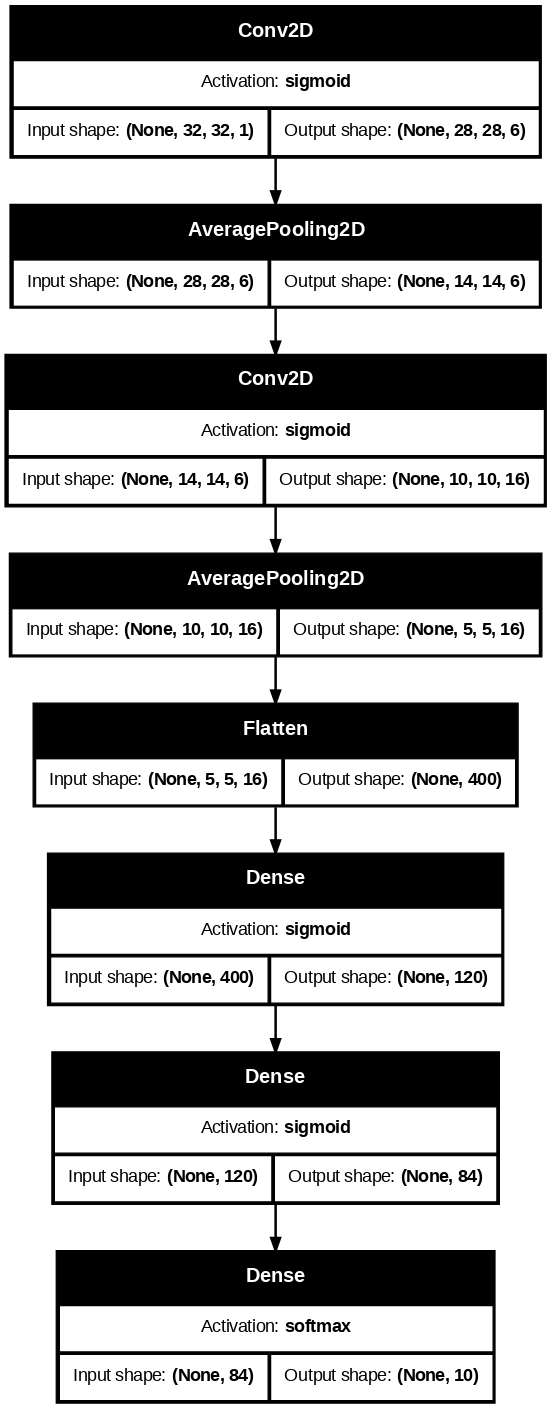

In [ ]:
keras.utils.plot_model(
    lenet5,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_sequential_lenet5.png"
)

In [ ]:
X_train.shape

(50000, 28, 28)

In [ ]:
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)
X_val_cnn = np.expand_dims(X_val, axis=-1)

In [ ]:
X_train_cnn = tf.image.resize(X_train_cnn, [32, 32]).numpy()
X_test_cnn = tf.image.resize(X_test_cnn, [32, 32]).numpy()
X_val_cnn = tf.image.resize(X_val_cnn, [32, 32]).numpy()

In [ ]:
print(X_train_cnn.shape)
print(X_test_cnn.shape)
print(X_val_cnn.shape)

(50000, 32, 32, 1)
(10000, 32, 32, 1)
(10000, 32, 32, 1)


In [ ]:
lenet5.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.CategoricalAccuracy()]
)

In [ ]:
# 6. Train
history2 = lenet5.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val),
    epochs=10, batch_size=256)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 189ms/step - categorical_accuracy: 0.0558 - loss: 1.1464 - val_categorical_accuracy: 0.0733 - val_loss: 0.8930
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 208ms/step - categorical_accuracy: 0.0665 - loss: 0.8115 - val_categorical_accuracy: 0.0696 - val_loss: 0.7595
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 32s 161ms/step - categorical_accuracy: 0.0652 - loss: 0.7077 - val_categorical_accuracy: 0.0700 - val_loss: 0.6811
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - categorical_accuracy: 0.0702 - loss: 0.6523 - val_categorical_accuracy: 0.0711 - val_loss: 0.6329
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - categorical_accuracy: 0.0638 - loss: 0.6123 - val_categorical_accuracy: 0.0717 - val_loss: 0.6004
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 192ms/step - categorical_accuracy: 0.0677 - loss: 0.5786 - val_categorical_accuracy: 0.0712 - val_loss: 0.5721
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - categorical_a

In [ ]:
pd.DataFrame(history2.history).to_csv("./keras_sequential_history2.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_sequential_history2.csv](./Modul7/keras_sequential_history2.csv)

In [ ]:
history2_df = pd.read_csv("./keras_sequential_history2.csv")

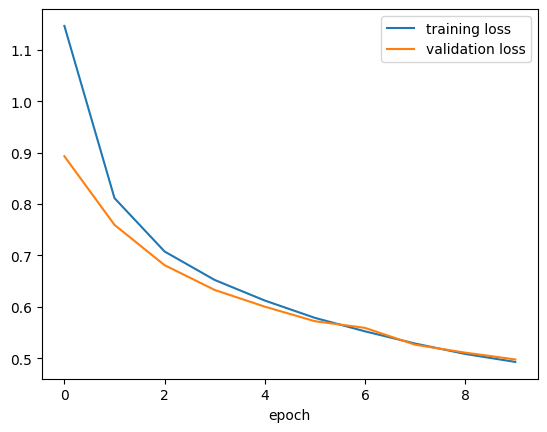

In [ ]:
plt.plot(history2_df["loss"], label = "training loss")
plt.plot(history2_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [ ]:
lenet5.save("./keras_sequential_lenet5.keras")

## Hasil Prediksi

In [ ]:
y_pred2 = lenet5.predict(X_test_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
y_pred_labels2 = np.argmax(y_pred2, axis=1)

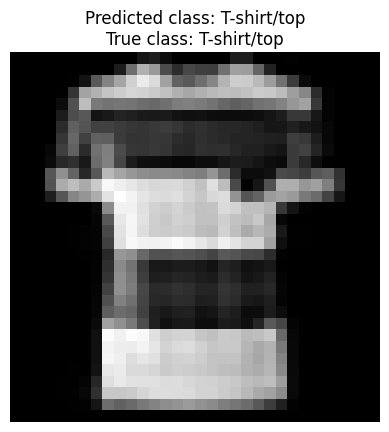

In [ ]:
#@title Slider to look for some prediction examples {run: "auto"}
idx = 2099 #@param {type:"slider", min:0, max:9999, step:1}

plt.imshow(X_test_cnn[idx], cmap='gray')
plt.title(
    f"Predicted class: {class_names[int(np.argmax(y_pred2[idx]))]}\n" +
    f"True class: {class_names[y_test[idx]]}"
)
plt.axis('OFF')
plt.show()

Confusion matrix, without normalization
[[870   3  25  52   5   1  30   0  14   0]
 [  5 953   6  27   4   0   4   0   1   0]
 [ 13   2 739   9 150   0  78   0   9   0]
 [ 49  24  19 847  18   1  38   0   4   0]
 [  3   2 161  60 701   1  66   0   6   0]
 [  0   0   0   2   0 949   0  35   3  11]
 [281   3 291  41 155   0 203   0  26   0]
 [  0   0   0   0   0  48   0 933   0  19]
 [  5   2  19   8   2   3  14   4 942   1]
 [  0   0   0   0   0  28   0  65   1 906]]


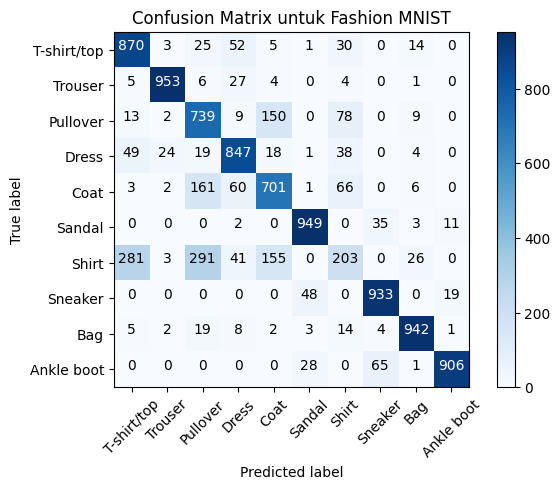

In [ ]:
cm2 = confusion_matrix(y_test, y_pred_labels2, labels=np.arange(len(class_names)))

plot_confusion_matrix(cm2, class_names, title='Confusion Matrix untuk Fashion MNIST', normalize=False)
plt.show()

# Transfer learning

In [ ]:
import tensorflow as tf
from keras import layers, models, applications

In [ ]:
X_train_tl = np.stack((X_train,) * 3, axis=-1)
X_test_tl = np.stack((X_test,) * 3, axis=-1)
X_val_tl = np.stack((X_val,) * 3, axis=-1)

In [ ]:
X_train_tl.shape

(50000, 28, 28, 3)

In [ ]:
X_train_tl = tf.image.resize(X_train_tl, [32, 32]).numpy()
X_test_tl = tf.image.resize(X_test_tl, [32, 32]).numpy()
X_val_tl = tf.image.resize(X_val_tl, [32, 32]).numpy()

In [ ]:
X_train_tl.shape

(50000, 32, 32, 3)

In [ ]:
keras.backend.clear_session()

In [ ]:
# ResNet-50 Model
base_model = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze base layers for initial training
base_model.trainable = False

model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,719,498 (90.48 MB)

 Trainable params: 131,786 (514.79 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

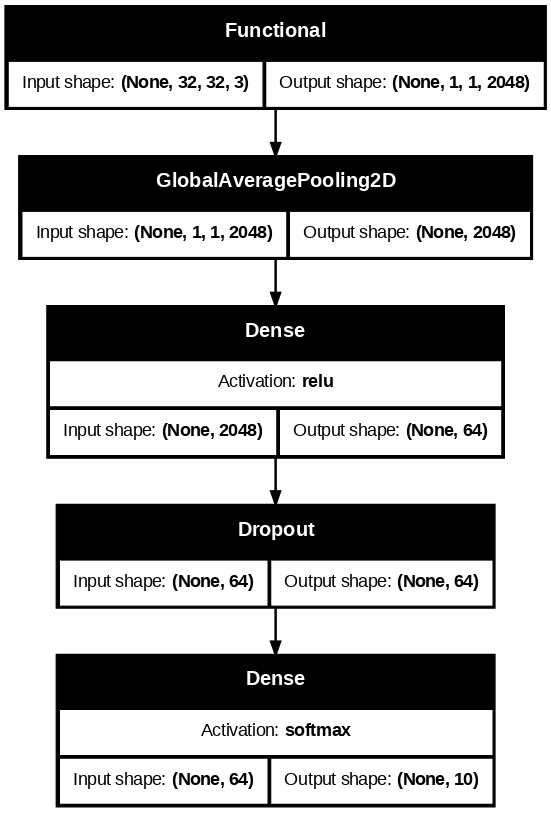

In [ ]:
keras.utils.plot_model(
    model2,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_sequential_resnet50.png"
)

In [ ]:
# 5. Compile
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train
history3 = model2.fit(X_train_tl, y_train, validation_data=(X_val_tl, y_val),
    epochs=5, batch_size=256)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.3986 - loss: 1.6395 - val_accuracy: 0.6404 - val_loss: 1.1456
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 193s 985ms/step - accuracy: 0.5698 - loss: 1.1568 - val_accuracy: 0.6851 - val_loss: 0.9344
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6227 - loss: 1.0221 - val_accuracy: 0.6952 - val_loss: 0.8584
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 181s 925ms/step - accuracy: 0.6518 - loss: 0.9474 - val_accuracy: 0.7220 - val_loss: 0.7876
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.6640 - loss: 0.9065 - val_accuracy: 0.7268 - val_loss: 0.7639


In [ ]:
pd.DataFrame(history3.history).to_csv("./keras_sequential_history3.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_sequential_history3.csv](./Modul7/keras_sequential_history3.csv)

In [ ]:
history3_df = pd.read_csv("./keras_sequential_history3.csv")

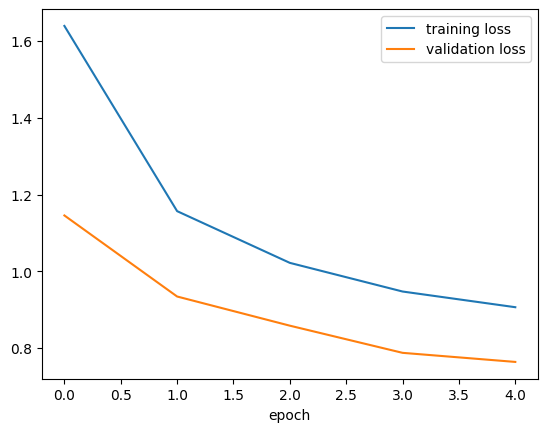

In [ ]:
plt.plot(history3_df["loss"], label = "training loss")
plt.plot(history3_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [ ]:
model2.save("./Resnet50_transfer_learn.keras")

## Hasil Prediksi

In [ ]:
y_pred3 = model2.predict(X_test_tl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 133ms/step


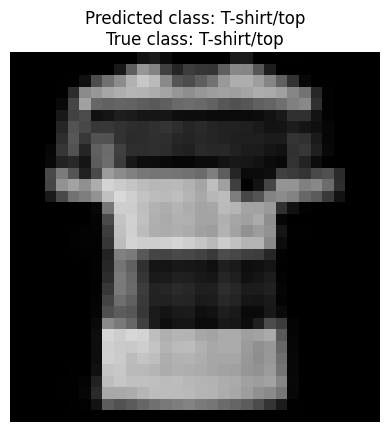

In [ ]:
#@title Slider to look for some prediction examples {run: "auto"}
idx = 2099 #@param {type:"slider", min:0, max:9999, step:1}

plt.imshow(X_test_tl[idx], cmap='gray')
plt.title(
    f"Predicted class: {class_names[int(np.argmax(y_pred3[idx]))]}\n" +
    f"True class: {class_names[y_test[idx]]}"
)
plt.axis('OFF')
plt.show()

Confusion matrix, without normalization
[[680  33  23  66  34   3 116   0  45   0]
 [  3 935   9  28  13   0  10   0   2   0]
 [ 28   3 541   8 219   0 173   0  28   0]
 [ 53 103   8 680  72   1  73   0  10   0]
 [ 15   4 190  66 588   1 122   0  14   0]
 [  2   0   0   1   0 840   0  95  11  51]
 [187  22 213  45 167   0 327   0  39   0]
 [  0   0   0   0   0  79   0 792   1 128]
 [  6   0   9   6  12  12  32   8 910   5]
 [  1   0   0   2   0   8   0  36   0 953]]


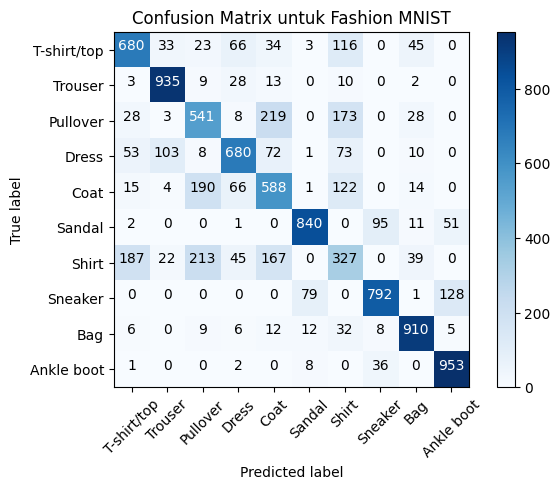

In [ ]:
y_pred_labels3 = np.argmax(y_pred3, axis=1)
cm3 = confusion_matrix(y_test, y_pred_labels3, labels=np.arange(len(class_names)))

plot_confusion_matrix(cm3, class_names, title='Confusion Matrix untuk Fashion MNIST', normalize=False)
plt.show()

# Referensi

Sumber gambar

- Aggarwal, C. Charu. 2018. *Neural Networks and Deep Learning: A Textbook.* Edisi Pertama. Springer.

- Goodfellow, Ian; Bengio, Yoshua; & Courville, Aaron. 2016. *Deep Learning*. MIT Press.

- Kotu, Data Science Concepts and Practice